In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
# Patch Embedding

Size2D = int | tuple[int, int]


def to_pair(
    value: Size2D,
) -> tuple[int, int]:
    if isinstance(value, int):
        return (value, value)
    return value


class PatchEmbedding(nn.Module):
    def __init__(
        self,
        image_size: Size2D = 96,
        patch_size: Size2D = 16,
        num_hiddens: int = 512,
    ) -> None:
        super().__init__()

        image_height, image_width = to_pair(image_size)
        patch_height, patch_width = to_pair(patch_size)

        self.num_patches = (
            image_height // patch_height
        ) * (
            image_width // patch_width
        )

        self.conv = nn.LazyConv2d(
            out_channels=num_hiddens,
            kernel_size=(patch_height, patch_width),
            stride=(patch_height, patch_width),
        )

    def forward(
        self,
        X: torch.Tensor,
    ) -> torch.Tensor:
        # [B, C, H, W] -> [B, D, H/P, W/P]
        X = self.conv(X)

        # [B, D, H/P, W/P] -> [B, M, D]
        return X.flatten(
            start_dim=2
        ).transpose(1, 2)

In [3]:
# Vision Transformer MLP

class ViTMLP(nn.Module):
    def __init__(
        self,
        mlp_num_hiddens: int,
        mlp_num_outputs: int,
        dropout: float = 0.5,
    ) -> None:
        super().__init__()

        self.dense1 = nn.LazyLinear(
            out_features=mlp_num_hiddens,
        )
        self.gelu = nn.GELU()
        self.dropout1 = nn.Dropout(p=dropout)
        self.dense2 = nn.LazyLinear(
            out_features=mlp_num_outputs,
        )
        self.dropout2 = nn.Dropout(p=dropout)

    def forward(
        self,
        X: torch.Tensor,
    ) -> torch.Tensor:
        X = self.dense1(X)
        X = self.gelu(X)
        X = self.dropout1(X)
        X = self.dense2(X)
        return self.dropout2(X)

In [4]:
# Vision Transformer Encoder Block

class ViTBlock(nn.Module):
    def __init__(
        self,
        num_hiddens: int,
        norm_shape: int,
        mlp_num_hiddens: int,
        num_heads: int,
        dropout: float,
        use_bias: bool = False,
    ) -> None:
        super().__init__()

        self.layer_norm1 = nn.LayerNorm(
            normalized_shape=norm_shape,
        )
        self.attention = d2l.MultiHeadAttention(
            num_hiddens=num_hiddens,
            num_heads=num_heads,
            dropout=dropout,
            bias=use_bias,
        )
        self.layer_norm2 = nn.LayerNorm(
            normalized_shape=norm_shape,
        )
        self.mlp = ViTMLP(
            mlp_num_hiddens=mlp_num_hiddens,
            mlp_num_outputs=num_hiddens,
            dropout=dropout,
        )

    def forward(
        self,
        X: torch.Tensor,
        valid_lens: torch.Tensor | None = None,
    ) -> torch.Tensor:
        # Pre-Normalization Self-Attention
        normalized_X = self.layer_norm1(X)
        attention_output = self.attention(
            queries=normalized_X,
            keys=normalized_X,
            values=normalized_X,
            valid_lens=valid_lens,
        )
        X = X + attention_output

        # Pre-Normalization MLP
        return X + self.mlp(
            self.layer_norm2(X)
        )

In [5]:
# Vision Transformer

class ViT(d2l.Classifier):
    def __init__(
        self,
        image_size: Size2D,
        patch_size: Size2D,
        num_hiddens: int,
        mlp_num_hiddens: int,
        num_heads: int,
        num_blocks: int,
        embedding_dropout: float,
        block_dropout: float,
        lr: float = 0.1,
        use_bias: bool = False,
        num_classes: int = 10,
    ) -> None:
        super().__init__()
        self.save_hyperparameters()

        self.patch_embedding = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            num_hiddens=num_hiddens,
        )

        self.class_token = nn.Parameter(
            torch.zeros(1, 1, num_hiddens)
        )

        num_steps = (
            self.patch_embedding.num_patches + 1
        )

        self.positional_embedding = nn.Parameter(
            torch.randn(1, num_steps, num_hiddens)
        )
        self.dropout = nn.Dropout(
            p=embedding_dropout,
        )

        self.blocks = nn.Sequential(
            *[
                ViTBlock(
                    num_hiddens=num_hiddens,
                    norm_shape=num_hiddens,
                    mlp_num_hiddens=mlp_num_hiddens,
                    num_heads=num_heads,
                    dropout=block_dropout,
                    use_bias=use_bias,
                )
                for _ in range(num_blocks)
            ]
        )

        self.head = nn.Sequential(
            nn.LayerNorm(num_hiddens),
            nn.Linear(num_hiddens, num_classes),
        )

    def forward(
        self,
        X: torch.Tensor,
    ) -> torch.Tensor:
        
        # [B, C, H, W] -> [B, M, D]
        X = self.patch_embedding(X)

        # [1, 1, D] -> [B, 1, D]
        class_tokens = self.class_token.expand(
            X.shape[0],
            -1,
            -1,
        )
        
        # [B, 1, D] + [B, M, D] -> [B, M+1, D]
        X = torch.cat(
            (class_tokens, X),
            dim=1,
        )
        
        # Patch 순서 정보 추가
        X = self.dropout(
            X + self.positional_embedding
        )

        for block in self.blocks:
            if not isinstance(
                block,
                ViTBlock,
            ):
                raise TypeError(
                    "Every encoder block must be a ViTBlock."
                )
            
            X = block(X)
        
        # <cls> Representation만 Classification에 사용
        return self.head(X[:, 0])

In [6]:
# Vision Transformer Data Flow 검증

test_model = ViT(
    image_size=96,
    patch_size=16,
    num_hiddens=24,
    mlp_num_hiddens=48,
    num_heads=8,
    num_blocks=2,
    embedding_dropout=0.1,
    block_dropout=0.1,
)
test_model.eval()

images = torch.zeros((2, 1, 96, 96))

with torch.no_grad():
    patch_tokens = test_model.patch_embedding(images)
    class_tokens = test_model.class_token.expand(
        images.shape[0],
        -1,
        -1,
    )
    token_sequence = torch.cat(
        (class_tokens, patch_tokens),
        dim=1,
    )
    logits = test_model(images)

print("Images:", tuple(images.shape))
print("Patch tokens:", tuple(patch_tokens.shape))
print("Class tokens:", tuple(class_tokens.shape))
print("Token sequence:", tuple(token_sequence.shape))
print("Logits:", tuple(logits.shape))

d2l.check_shape(patch_tokens, (2, 36, 24))
d2l.check_shape(token_sequence, (2, 37, 24))
d2l.check_shape(logits, (2, 10))

Images: (2, 1, 96, 96)
Patch tokens: (2, 36, 24)
Class tokens: (2, 1, 24)
Token sequence: (2, 37, 24)
Logits: (2, 10)


In [7]:
# Fashion-MNIST와 원문 ViT 설정

image_size = 96
patch_size = 16
num_hiddens = 512
mlp_num_hiddens = 2048
num_heads = 8
num_blocks = 2
embedding_dropout = 0.1
block_dropout = 0.1
learning_rate = 0.1
batch_size = 128

model = ViT(
    image_size=image_size,
    patch_size=patch_size,
    num_hiddens=num_hiddens,
    mlp_num_hiddens=mlp_num_hiddens,
    num_heads=num_heads,
    num_blocks=num_blocks,
    embedding_dropout=embedding_dropout,
    block_dropout=block_dropout,
    lr=learning_rate,
)

# Lazy Layer materialization과 Output shape 확인
sample_images = torch.zeros((1, 1, image_size, image_size))
model.eval()
with torch.no_grad():
    sample_logits = model(sample_images)

num_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

device = d2l.try_gpu()
num_gpus = 1 if torch.cuda.is_available() else 0

print("Device:", device)
print("Sample logits:", tuple(sample_logits.shape))
print("Trainable parameters:", f"{num_parameters:,}")

d2l.check_shape(sample_logits, (1, 10))

data = d2l.FashionMNIST(
    batch_size=batch_size,
    resize=(image_size, image_size),
)

trainer = d2l.Trainer(
    max_epochs=10,
    num_gpus=num_gpus,
)

Device: cuda:0
Sample logits: (1, 10)
Trainable parameters: 6,457,866


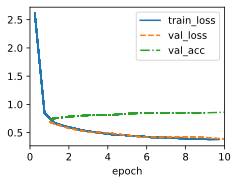

In [8]:
# Vision Transformer Training

trainer.fit(
    model,
    data,
)

In [9]:
# Numerical Validation

model.eval()
validation_loss_sum = 0.0
num_correct = 0
num_examples = 0

loss_function = nn.CrossEntropyLoss(
    reduction="sum",
)

with torch.no_grad():
    for X, y in data.val_dataloader():
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        validation_loss_sum += loss_function(
            logits,
            y,
        ).item()
        num_correct += (
            logits.argmax(dim=1) == y
        ).sum().item()
        num_examples += y.numel()

validation_loss = (
    validation_loss_sum / num_examples
)
validation_accuracy = (
    num_correct / num_examples
)

print(
    "Validation loss:",
    f"{validation_loss:.4f}",
)
print(
    "Validation accuracy:",
    f"{validation_accuracy:.4f}",
)

Validation loss: 0.3867
Validation accuracy: 0.8588
